In [16]:
import os
import random
import numpy as np
from keras import ops
from PIL import Image
from keras.applications.resnet_v2 import preprocess_input
import matplotlib.pyplot as plt
import keras
import warnings
warnings.filterwarnings('ignore')

**Dataset Path**

In [17]:
LFW_DIR = "LFW/"
IMAGE_DIR = os.path.join(LFW_DIR, "lfw-deepfunneled")
PAIRS_FILE = os.path.join(LFW_DIR, "pairs.csv")

Load LFW dataset and Create pairs

In [18]:
def load_and_pair_creation_of_data(base_path, link_file, resize_shape):
    import os
    import numpy as np
    from PIL import Image

    paired_images = []
    pair_flags = []

    matches_same = []
    matches_diff = []

    with open(link_file, 'r') as reader:
        next(reader)  # ignore the first header line
        for record in reader.readlines():
            elements = record.strip().split(',')
            if len(elements) == 3 or (len(elements) == 4 and elements[3] == ''):
                person_id, img_idx1, img_idx2 = elements[0], int(elements[1]), int(elements[2])
                img_path1 = os.path.join(base_path, person_id, f"{person_id}_{img_idx1:04d}.jpg")
                img_path2 = os.path.join(base_path, person_id, f"{person_id}_{img_idx2:04d}.jpg")
                matches_same.append([img_path1, img_path2])
            elif len(elements) == 4:
                person_a, idx_a, person_b, idx_b = elements[0], int(elements[1]), elements[2], int(elements[3])
                img_path1 = os.path.join(base_path, person_a, f"{person_a}_{idx_a:04d}.jpg")
                img_path2 = os.path.join(base_path, person_b, f"{person_b}_{idx_b:04d}.jpg")
                matches_diff.append([img_path1, img_path2])

    total_pairs = matches_same + matches_diff
    flags = [0] * len(matches_same) + [1] * len(matches_diff)

    print(f"Attempting to load {len(total_pairs) * 2} image files...")
    for i in range(len(total_pairs)):
        try:
            file1, file2 = total_pairs[i]

            image1 = Image.open(file1).convert("RGB").resize(resize_shape)
            image2 = Image.open(file2).convert("RGB").resize(resize_shape)

            array1 = np.array(image1, dtype="float32")
            array2 = np.array(image2, dtype="float32")

            paired_images.append([array1, array2])
            pair_flags.append(flags[i])

        except FileNotFoundError:
            print(f"Notice: Missing image(s) in pair #{i}. Skipping.")
            continue

    print("All images loaded successfully.")
    return np.array(paired_images), np.array(pair_flags, dtype="float32")


# ------------- Execution Section -------------

data_pairs, data_labels = load_and_pair_creation_of_data(IMAGE_DIR, PAIRS_FILE, (128, 128))

# Shuffle data randomly
shuffle_order = np.random.permutation(len(data_pairs))
data_pairs = data_pairs[shuffle_order]
data_labels = data_labels[shuffle_order]

# Primary 80/20 split for training+validation and testing
main_split = int(0.8 * len(data_pairs))
data_tv, labels_tv = data_pairs[:main_split], data_labels[:main_split]
data_test, labels_test = data_pairs[main_split:], data_labels[main_split:]

# Secondary 50/50 split of training+validation into train and validation
sub_split = int(0.5 * len(data_tv))
data_train, labels_train = data_tv[:sub_split], labels_tv[:sub_split]
data_val, labels_val = data_tv[sub_split:], labels_tv[sub_split:]

print(f"\nTotal processed pairs: {len(data_pairs)}")
print("---")
print(f"Train set size:       {len(data_train)}")
print(f"Validation set size:  {len(data_val)}")
print(f"Test set size:        {len(data_test)}")
print("---")
print(f"Train pair shape:     {data_train.shape}")


Attempting to load 12000 image files...


All images loaded successfully.

Total processed pairs: 6000
---
Train set size:       2400
Validation set size:  2400
Test set size:        1200
---
Train pair shape:     (2400, 2, 128, 128, 3)


Split and preprocess the dataset

In [19]:
# Split the training pairs
x_train_1 = preprocess_input(data_train[:, 0])
x_train_2 = preprocess_input(data_train[:, 1])

# Split the test pairs
x_test_1 = preprocess_input(data_test[:, 0])
x_test_2 = preprocess_input(data_test[:, 1])

# Split the test pairs
x_val_1 = preprocess_input(data_val[:, 0])
x_val_2 = preprocess_input(data_val[:, 1])

**Define the model**

In [20]:
def euclidean_distance(vects):
    x, y = vects
    sum_square = ops.sum(ops.square(x - y), axis=1, keepdims=True)
    return ops.sqrt(ops.maximum(sum_square, keras.backend.epsilon()))

def create_embedding_network(input_shape):
    # Define the ResNet50V2 base model
    base_cnn = keras.applications.ResNet50V2(
        weights="imagenet", 
        input_shape=input_shape,
        include_top=False,
    )

    # Set layers to be trainable as requested
    trainable = False
    for layer in base_cnn.layers:
        if layer.name == "conv5_block1_out":
            trainable = True
        layer.trainable = trainable

    # Add a custom head for embedding generation
    flatten = keras.layers.Flatten()(base_cnn.output)
    x = keras.layers.Dense(512, activation="relu")(flatten)
    x = keras.layers.BatchNormalization()(x)
    output = keras.layers.Dense(256)(x) # 256-dimensional embedding

    return keras.Model(base_cnn.input, output, name="Embedding")

# Define the input shape for our LFW images
input_shape = (128,128,3)
embedding_network = create_embedding_network(input_shape)

# The Siamese network structure is IDENTICAL to the blog's
input_1 = keras.layers.Input(input_shape)
input_2 = keras.layers.Input(input_shape)

tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))(
    [tower_1, tower_2]
)
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese_model = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

**Define Contrastive Loss Function and compile the model**

In [21]:
def loss(margin=1):
    def contrastive_loss(y_true, y_pred):
        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - y_pred, 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)
    return contrastive_loss

siamese_model.compile(loss=loss(), optimizer=keras.optimizers.Adam(0.0001), metrics=["accuracy"])
siamese_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 256)       │ 40,475,904 │ input_layer_7[0]… │
│ (Functional)        │                   │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ Embedding[0][0],  │
│                     │                   │            │ Embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1)         │          4 │ lambda_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │          2 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,475,910 (154.40 MB)

 Trainable params: 25,843,460 (98.58 MB)

 Non-trainable params: 14,632,450 (55.82 MB)

**Train the model**

In [22]:
history = siamese_model.fit(
    [x_train_1, x_train_2],
    labels_train,
    validation_data=([x_val_1, x_val_2], labels_val),
    batch_size=16,
    epochs=30,
)

Epoch 1/30


150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6140 - loss: 0.2346 - val_accuracy: 0.5196 - val_loss: 0.3346
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9184 - loss: 0.1423 - val_accuracy: 0.6892 - val_loss: 0.2034
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9800 - loss: 0.1226 - val_accuracy: 0.7175 - val_loss: 0.1978
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9823 - loss: 0.1184 - val_accuracy: 0.7275 - val_loss: 0.1964
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9925 - loss: 0.1111 - val_accuracy: 0.7312 - val_loss: 0.1932
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9867 - loss: 0.1108 - val_accuracy: 0.7350 - val_loss: 0.1915
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9867 - loss: 0.1048 - val_accuracy: 0.7275 - val_loss: 0.1919
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9843 - loss: 0.1035 - val_accuracy: 0.73

**Visualize the Accuracy and Loss**

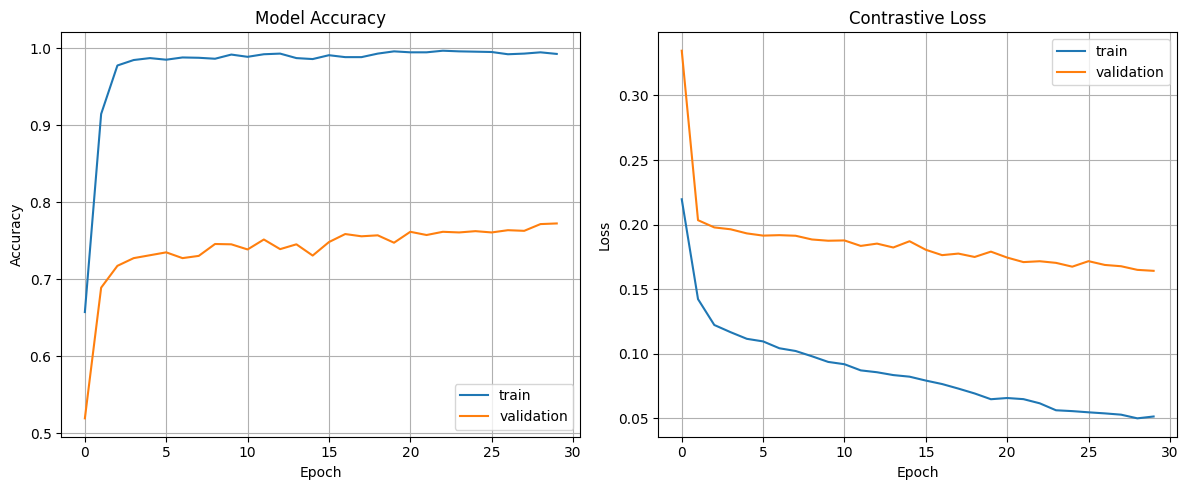

In [23]:
def plt_combined_metrics(history, has_valid=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Plot Accuracy ---
    axes[0].plot(history.history["accuracy"], label="train")
    if has_valid and "val_accuracy" in history.history:
        axes[0].plot(history.history["val_accuracy"], label="validation")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # --- Plot Loss ---
    axes[1].plot(history.history["loss"], label="train")
    if has_valid and "val_loss" in history.history:
        axes[1].plot(history.history["val_loss"], label="validation")
    axes[1].set_title("Contrastive Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# execute the plotting function
plt_combined_metrics(history)

In [25]:
results = siamese_model.evaluate([x_test_1, x_test_2], labels_test, batch_size=16)
print("\nTest Loss, Test Acc:", results)

63/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8019 - loss: 0.1550

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7978 - loss: 0.1568

Test Loss, Test Acc: [0.16712217032909393, 0.7733333110809326]


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


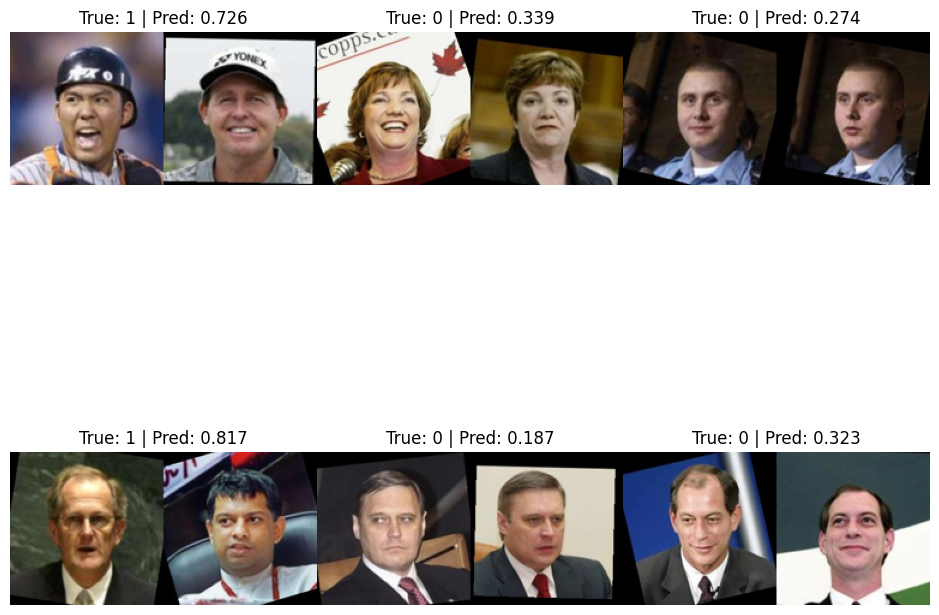

In [27]:
def visualize(pairs, labels, to_show=6, num_col=3, predictions=None, test=False):
    num_row = to_show // num_col if to_show // num_col != 0 else 1
    to_show = num_row * num_col

    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))
    if to_show == 1:
        axes = [axes]
    if num_row > 1 and num_col > 1:
        axes = axes.flatten()

    for i in range(to_show):
        ax = axes[i]
        # We need to de-normalize the images from ResNet's [-1, 1] to [0, 1] for correct plotting
        img_pair_to_show = (pairs[i] / 2.0) + 0.5
        ax.imshow(ops.concatenate([img_pair_to_show[0], img_pair_to_show[1]], axis=1))
        ax.set_axis_off()
        if test:
            ax.set_title("True: {} | Pred: {:.3f}".format(int(labels[i]), predictions[i][0]))
        else:
            ax.set_title("Label: {}".format(int(labels[i])))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    # plt.tight_layout()
    plt.show()

predictions = siamese_model.predict([x_test_1, x_test_2])
visualize(data_test, labels_test, to_show=6, predictions=predictions, test=True)